# Exploration of PRISM heat data

In [1]:
from datetime import datetime, timedelta, date
import math

import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
import numpy as np
import orjson
import pandas as pd
import polars as pl
import seaborn as sns
import shapely
from shapely import wkb
from tqdm import tqdm

from wpp import data, db, plot
from wpp.utils import project_root

In [2]:
# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

root = project_root()
db_path = root / "wpp.duckdb"
con = db.connect(db_path)

## PRISM cells

In [16]:
query = """
    SELECT
        pc.* EXCLUDE (GEOM),
        ST_AsText(pc.GEOM) AS WKT,
        t.*
    FROM prism_cells pc
    JOIN prism_tmean_daily t
        ON pc.CELL_ID = t.CELL_ID
    WHERE t.DATE = DATE '2025-01-01'
"""

prism = con.sql(query).pl()

prism_gdf = gpd.GeoDataFrame(
    prism.to_pandas(),
    geometry=gpd.GeoSeries.from_wkt(prism["WKT"].to_list()),
    crs="EPSG:4326",
).drop(columns=["WKT"])

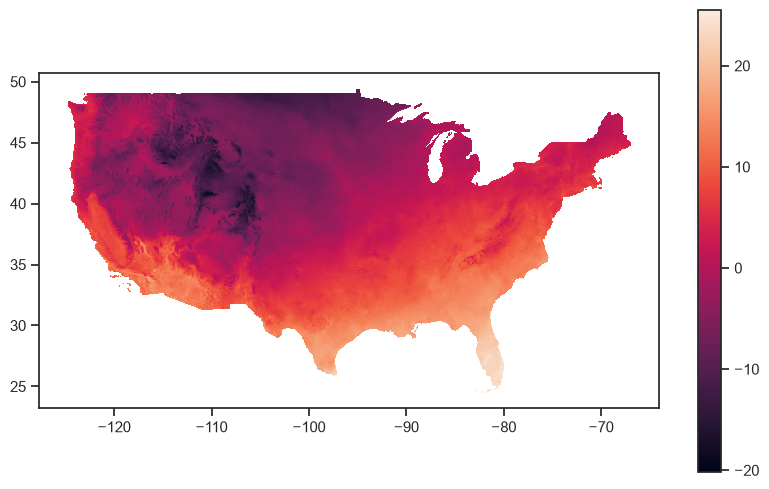

In [17]:
ax = prism_gdf.plot(
    column="TMEAN",
    figsize=(10, 6),
    legend=True,
    edgecolor="none",
    linewidth=0,
)
plt.show()

## Top 100 CBSA heat plots

In [22]:
query = """
    SELECT 
        * EXCLUDE (GEOM),
        ST_AsText(GEOM) AS WKT,
        POP_RANK_IN_TYPE <= 100 AND LSAD = 'M1'AS IS_TOP
    FROM cbsa
"""
cbsa = con.sql(query).pl()

cbsa_gdf = gpd.GeoDataFrame(
    cbsa.to_pandas(),
    geometry=gpd.GeoSeries.from_wkt(cbsa["WKT"].to_list()),
    crs="EPSG:4326",
).drop(columns=["WKT"])

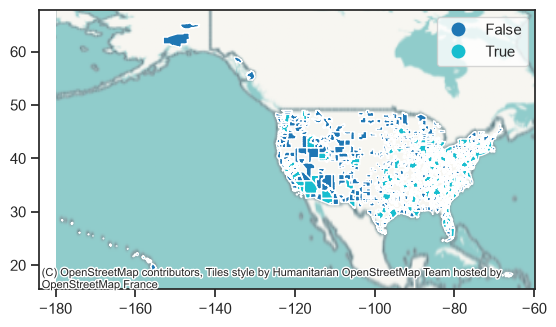

In [24]:
ax = cbsa_gdf.plot(column="IS_TOP", legend=True)
cx.add_basemap(ax, zoom='auto', crs="EPSG:4326")

In [25]:
query = """
    SELECT
        pc.* EXCLUDE (GEOM),
        ST_AsText(pc.GEOM) AS WKT,
        t.*
    FROM prism_cells pc
    JOIN prism_tmean_daily t
        ON pc.CELL_ID = t.CELL_ID
    JOIN cbsa_prism_cells cpc
        ON pc.CELL_ID = cpc.CELL_ID
    JOIN cbsa_top cbsa
        ON cpc.CBSAFP = cbsa.CBSAFP
    WHERE t.DATE = DATE '2025-01-01'
"""
cbsa_tmean = con.sql(query).pl()

cbsa_tmean_gdf = gpd.GeoDataFrame(
    cbsa_tmean.to_pandas(),
    geometry=gpd.GeoSeries.from_wkt(cbsa_tmean["WKT"].to_list()),
    crs="EPSG:4326",
).drop(columns=["WKT"])

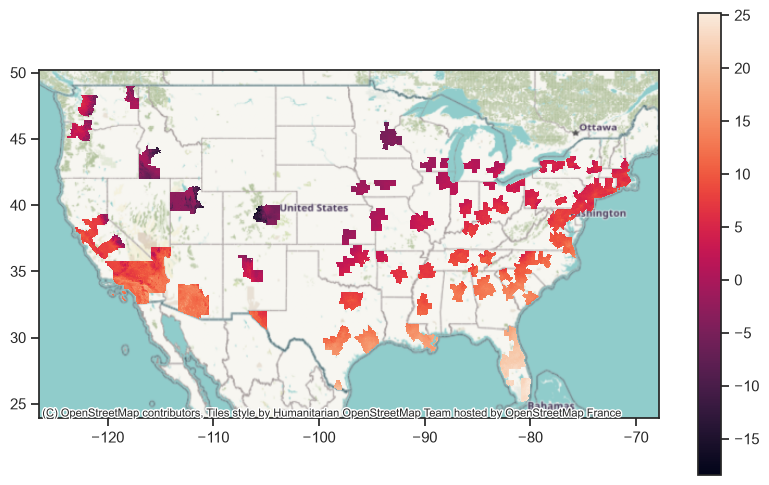

In [26]:
ax = cbsa_tmean_gdf.plot(
    column="TMEAN",
    figsize=(10, 6),
    legend=True,
    edgecolor="none",
    linewidth=0,
)
cx.add_basemap(ax, zoom='auto', crs="EPSG:4326")

### Top 100 CBSA over time

In [37]:
query = """
    SELECT
        cpc.CBSAFP, CBSA_NAME, DATE,
        AVG(TMEAN) AS AVG_TMEAN,
        SUM(CBSA_WEIGHT * TMEAN) AS WEIGHTED_TMEAN
    FROM prism_cells pc
    JOIN prism_tmean_daily t
        ON pc.CELL_ID = t.CELL_ID
    JOIN cbsa_prism_cells cpc
        ON pc.CELL_ID = cpc.CELL_ID
    JOIN cbsa_top cbsa
        ON cpc.CBSAFP = cbsa.CBSAFP
    GROUP BY 1, 2, 3
"""
avg_tmean = con.sql(query).pl().with_columns(
    pl.col("CBSA_NAME").str.ends_with(", FL").alias("IS_FLORIDA")
).with_columns(
    pl.when(pl.col("IS_FLORIDA")).then(pl.col("CBSA_NAME")).otherwise(pl.lit("Other")).alias("NAME")
)

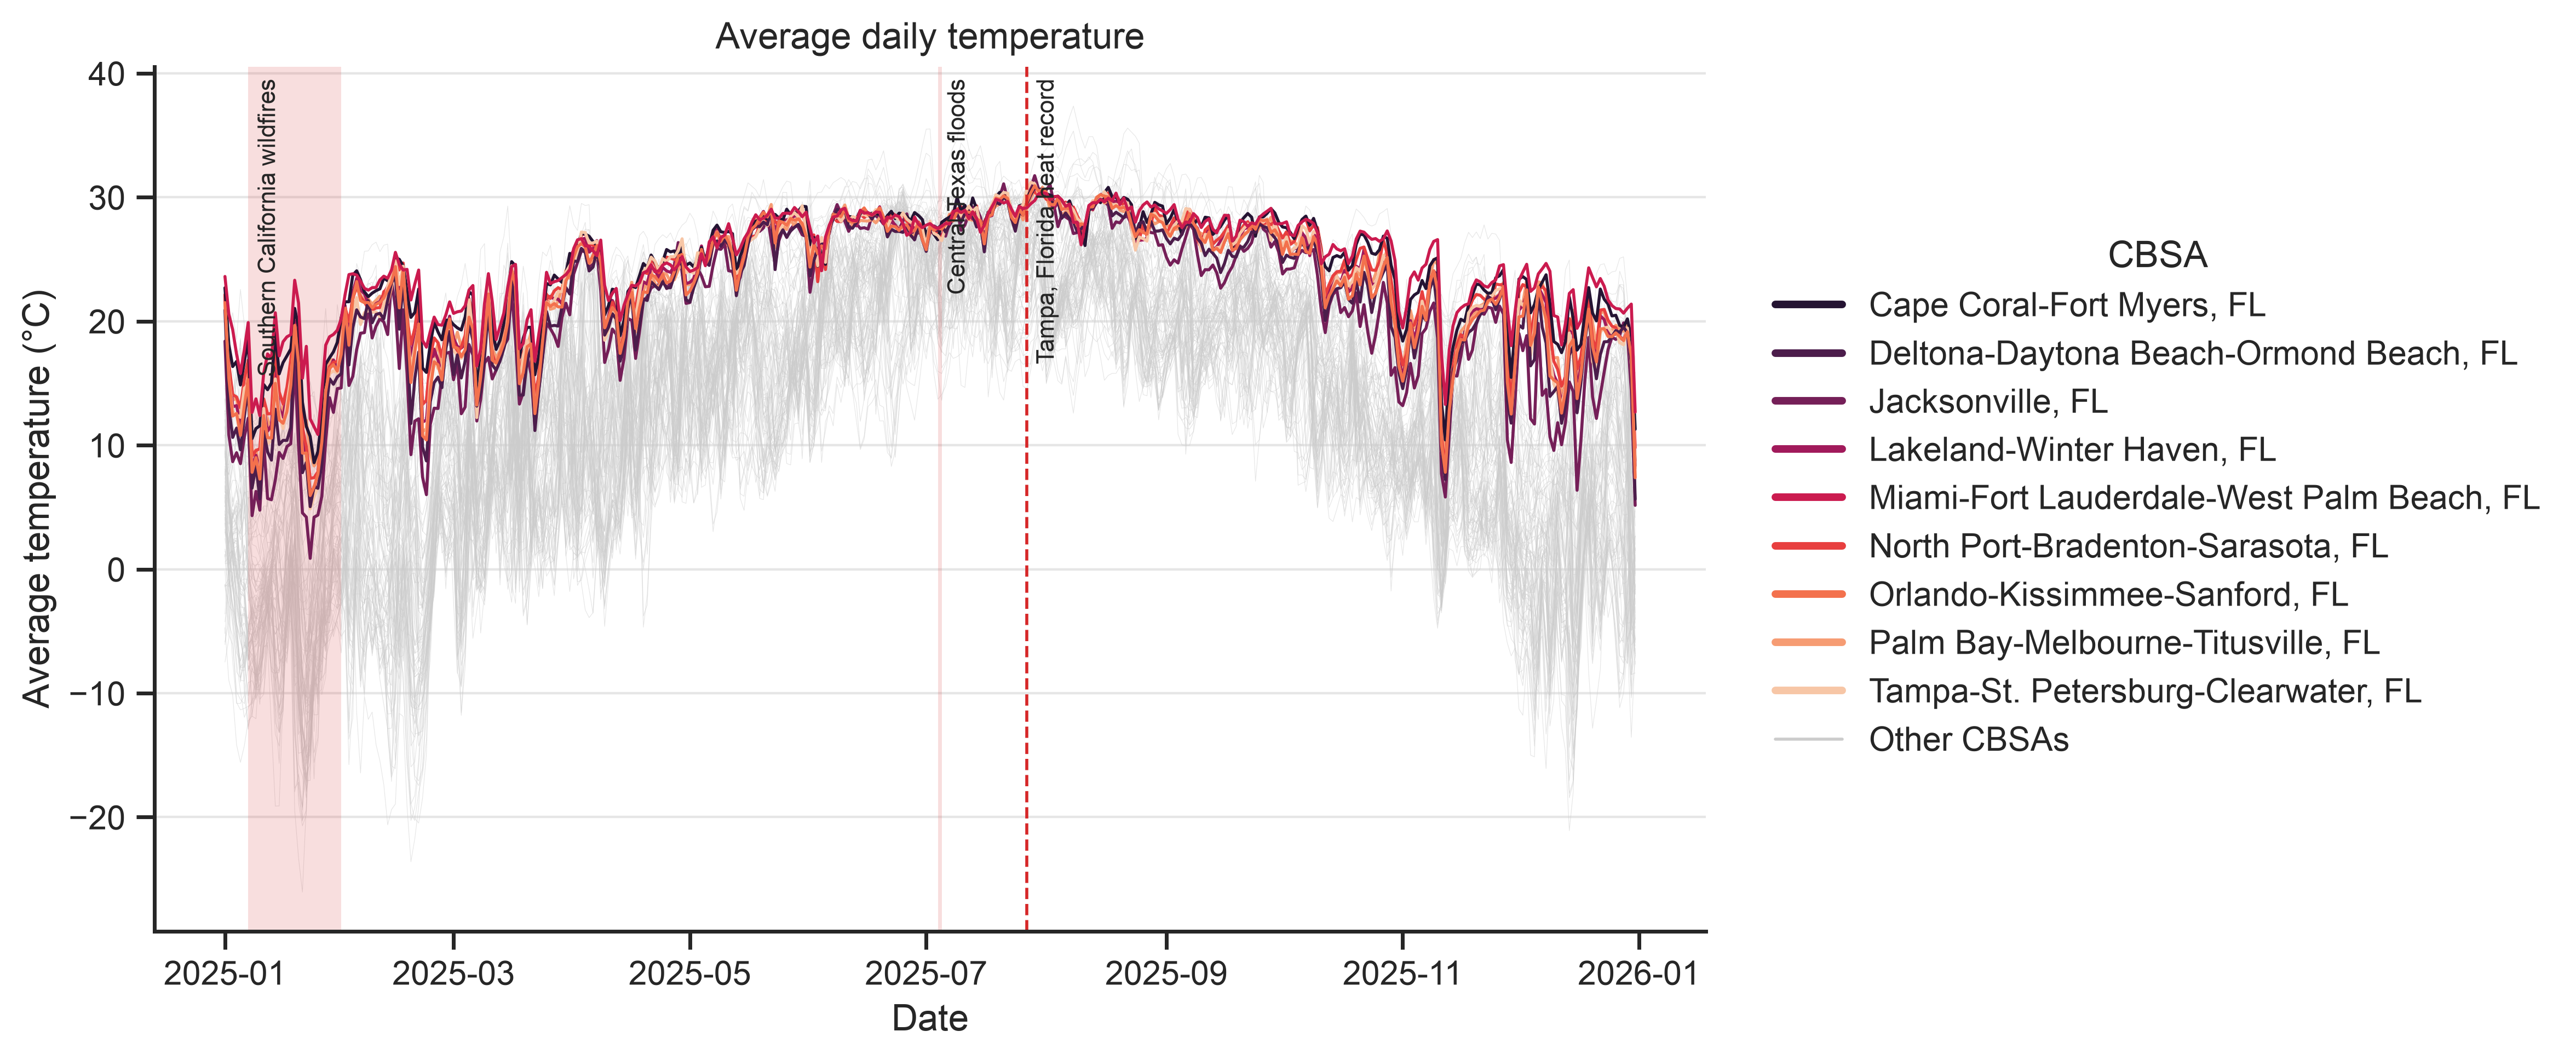

In [63]:
fig, (ax, ax_legend) = plt.subplots(
    1, 2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [4, 1]},
    dpi=400
)

florida_names = (
    avg_tmean
    .filter(pl.col("IS_FLORIDA"))
    .get_column("NAME")
    .unique()
    .sort()
    .to_list()
)

palette = dict(zip(
    florida_names,
    sns.color_palette("rocket", n_colors=len(florida_names))
))

for (name,), g in avg_tmean.group_by("CBSA_NAME", maintain_order=True):
    g = g.sort("DATE")
    is_florida = g["IS_FLORIDA"][0]

    ax.plot(
        g["DATE"],
        g["AVG_TMEAN"],
        linewidth=1 if is_florida else 0.2,
        color=palette[name] if is_florida else "0.8",
        alpha=1 if is_florida else 0.5,
        zorder=2 if is_florida else 1,
    )

ax.set(
    title="Average daily temperature",
    xlabel="Date",
    ylabel="Average temperature (°C)",
)
ax.grid(axis="y", color="0.9", linewidth=0.8)
sns.despine(ax=ax)

handles = [
    Line2D(
        [0], [0],
        color=palette[name],
        linewidth=2.5,
        label=name,
    )
    for name in florida_names
]
handles.append(
    Line2D(
        [0], [0],
        color="0.8",
        linewidth=1,
        label="Other CBSAs",
    )
)
ax_legend.legend(
    handles=handles,
    title="CBSA",
    loc="center left",
    frameon=False,
)
ax_legend.set_axis_off()

events = data.get_climate_events()
plot.plot_events(ax, events)

fig.tight_layout()
plt.show()

## Block Group heat plots

In [65]:
query = """
    SELECT 
        * EXCLUDE (GEOM),
        ST_AsText(GEOM) AS WKT
    FROM block_groups_cbsa
    WHERE CBSA_POP_RANK = 1
"""
bg = con.sql(query).pl()

bg_gdf = gpd.GeoDataFrame(
    bg.to_pandas(),
    geometry=gpd.GeoSeries.from_wkt(bg["WKT"].to_list()),
    crs="EPSG:4326",
).drop(columns=["WKT"])

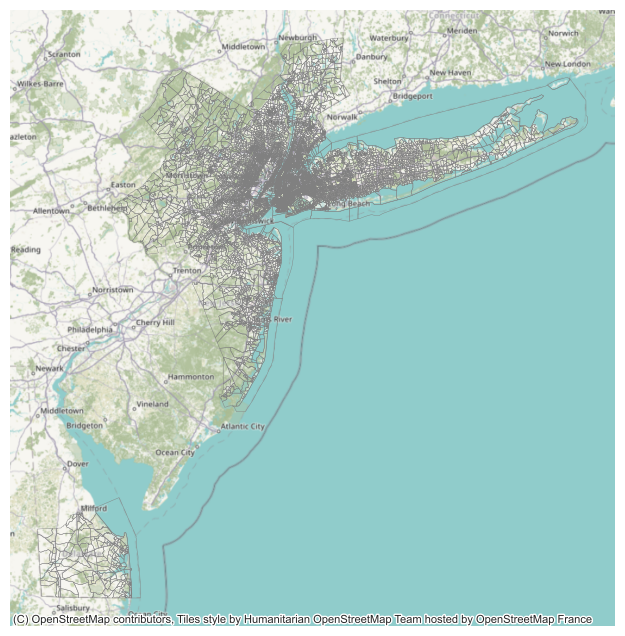

In [74]:
fig, ax = plt.subplots(figsize=(8,8))
bg_gdf.boundary.plot(linewidth=0.3, color='grey', ax=ax)
cx.add_basemap(ax, zoom='auto', crs='EPSG:4326')
ax.set_axis_off()

## Animation

In [4]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors as colors

# Geometry loaded once, with stable ordering
geometry_query = """
SELECT
    pc.CELL_ID,
    ST_AsText(pc.GEOM) AS WKT
FROM prism_cells pc
ORDER BY pc.CELL_ID
"""

geometry_df = con.sql(geometry_query).pl()

prism_gdf = gpd.GeoDataFrame(
    geometry_df.to_pandas(),
    geometry=gpd.GeoSeries.from_wkt(geometry_df["WKT"].to_list()),
    crs="EPSG:4326",
).drop(columns="WKT")

dates = pd.date_range("2025-01-01", "2025-12-31")

# Fixed colour scale across the entire animation
vmin, vmax = con.sql("""
    SELECT MIN(TMEAN), MAX(TMEAN)
    FROM prism_tmean_daily
    WHERE DATE BETWEEN DATE '2025-01-01' AND DATE '2025-12-31'
""").fetchone()

norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = "coolwarm"


def get_temperature(date):
    query = f"""
    SELECT t.TMEAN
    FROM prism_cells pc
    LEFT JOIN prism_tmean_daily t
        ON pc.CELL_ID = t.CELL_ID
       AND t.DATE = DATE '{date:%Y-%m-%d}'
    ORDER BY pc.CELL_ID
    """

    return (
        con.sql(query)
        .pl()["TMEAN"]
        .cast(pl.Float32)
        .to_numpy()
    )


# Initial frame
initial_temperature = get_temperature(dates[0])

fig, ax = plt.subplots(figsize=(10, 6))

prism_gdf.assign(TMEAN=initial_temperature).plot(
    column="TMEAN",
    ax=ax,
    cmap=cmap,
    norm=norm,
    edgecolor="none",
    linewidth=0,
    rasterized=True,
)

collection = ax.collections[0]
title = ax.set_title(dates[0].strftime("%Y-%m-%d"))

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_axis_off()

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Mean temperature")


def update(date):
    collection.set_array(get_temperature(date))
    title.set_text(date.strftime("%Y-%m-%d"))
    return collection, title


ani = animation.FuncAnimation(
    fig,
    update,
    frames=dates,
    interval=100,
    blit=False,
)

ani.save(
    "prism_tmean_2025.gif",
    writer=animation.PillowWriter(fps=10),
    dpi=100,
)

plt.close(fig)